# IS455 — Part 2: CRISP-DM pipeline for `is_fraud` (single deliverable)

**Course:** Machine Learning in Python (IS 455) — rubric: business understanding → data understanding → preparation → modeling (classification + ensembles) → evaluation & tuning → feature selection → **serialization & deployment (Ch. 17)**.

This is the **only** fraud-model notebook in the repo. It builds an end-to-end **binary classifier** on **`shop.db`**: join **`orders`** + **`customers`**, predict **`orders.is_fraud`**.

**Data source for training:** Local SQLite (`ShopWeb/Data/shop.db`, `web/data/shop.db`, or `Data/shop.db`). The **same schema** applies when the live app uses **Turso** (see §7).

**Environment:** Python 3.10+ with `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, and stdlib `sqlite3` (no SQLAlchemy required to read `shop.db`).

```bash
# From the repository root:
pip install -r Notebooks/requirements.txt
```

Open in **Jupyter**, **VS Code**, or **Colab** (upload `shop.db` next to the notebook or use a copy from this repo). **Before submitting:** run **Run All** so every cell has outputs.


In [1]:
%matplotlib inline


In [2]:
import sqlite3
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG = 42
np.random.seed(RNG)


In [3]:
# Resolve path to shop.db (notebook lives in Notebooks/)
ROOT = Path.cwd()
if (ROOT / "shop.db").exists():
    DB_PATH = ROOT / "shop.db"
else:
    for candidate in [
        ROOT.parent / "ShopWeb" / "Data" / "shop.db",
        ROOT.parent / "web" / "data" / "shop.db",
        ROOT.parent / "Data" / "shop.db",
    ]:
        if candidate.exists():
            DB_PATH = candidate
            break
    else:
        raise FileNotFoundError(
            "Place shop.db next to this notebook, or use ShopWeb/Data/shop.db / web/data/shop.db in the repo."
        )

print(f"Database: {DB_PATH.resolve()}")


Database: /Users/isaacfox/FoxIS455DeploymentAssignment-1/ShopWeb/Data/shop.db


## 1) Business understanding (CRISP-DM)

**Business problem:** E-commerce orders sometimes involve **payment fraud**. Reviewing every order manually does not scale.

**Analytics problem:** Build a **binary classifier** that estimates whether `is_fraud = 1` using **order- and customer-level features** available at checkout time.

**Success criteria (measurable):**
- **Discrimination:** ROC-AUC on held-out data (ranking suspicious orders).
- **Operational:** Reasonable **precision/recall** tradeoff for a verification queue (tune threshold in production).
- **Deployment:** Serialized **pipeline** (preprocessing + model) loadable by batch or online scoring jobs (**Ch. 17**).

**Constraints:** Do not use **`risk_score`** as an input feature if it is produced by the same system you are training (label leakage). Here we **exclude** `risk_score` from predictors.


## 2) Data understanding & exploration (Ch. 6, 8)

**Ch. 6 — Feature-level exploration:** distributions, missingness, categorical frequencies.

**Ch. 8 — Relationships:** association of inputs with the target; multivariate structure (correlations among numerics).


In [4]:
SQL = """
SELECT
  o.order_id,
  o.customer_id,
  o.order_datetime,
  o.billing_zip,
  o.shipping_zip,
  o.shipping_state,
  o.payment_method,
  o.device_type,
  o.ip_country,
  o.promo_used,
  o.order_subtotal,
  o.shipping_fee,
  o.tax_amount,
  o.order_total,
  o.is_fraud,
  c.gender,
  c.customer_segment,
  c.loyalty_tier
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
"""

df = pd.read_sql_query(SQL, sqlite3.connect(DB_PATH))
df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")
df["order_hour"] = df["order_datetime"].dt.hour.fillna(-1).astype(int)
df["order_dow"] = df["order_datetime"].dt.dayofweek.fillna(-1).astype(int)

print("Shape:", df.shape)
print(df.head())
df.info()


Shape: (5001, 20)
   order_id  customer_id      order_datetime billing_zip shipping_zip  \
0         1            1 2025-11-29 00:51:07       28289        28289   
1         2            1 2025-09-01 10:25:59       28289        13888   
2         3            1 2025-12-15 07:24:41       28289        28289   
3         4            1 2025-11-06 18:21:19       28289        28289   
4         5            1 2025-11-30 05:34:15       28289        28289   

  shipping_state payment_method device_type ip_country  promo_used  \
0             CO           card      mobile         US           0   
1             NY           card     desktop         US           1   
2             CO           card      mobile         US           0   
3             CO           bank      mobile         US           1   
4             CO           card      mobile         CA           0   

   order_subtotal  shipping_fee  tax_amount  order_total  is_fraud  gender  \
0          662.95         15.44       46.30 

In [5]:
# Target prevalence (class imbalance)
vc = df["is_fraud"].value_counts()
print("Class counts:\n", vc)
print("Fraud rate:", f"{100 * vc.get(1, 0) / len(df):.2f}%")


Class counts:
 is_fraud
0    4683
1     318
Name: count, dtype: int64
Fraud rate: 6.36%


In [6]:
# Numeric summaries (Ch. 6)
num_cols = [
    "promo_used",
    "order_subtotal",
    "shipping_fee",
    "tax_amount",
    "order_total",
    "order_hour",
    "order_dow",
]
print(df[num_cols + ["is_fraud"]].groupby("is_fraud").mean())
print(df[num_cols].describe().T)


          promo_used  order_subtotal  shipping_fee  tax_amount  order_total  \
is_fraud                                                                      
0           0.250908      368.840645      9.648847   26.643442   405.132934   
1           0.270440      609.209843      9.955629   43.837579   663.003050   

          order_hour  order_dow  
is_fraud                         
0          11.515909   3.031390  
1          11.981132   2.962264  
                 count        mean         std   min     25%     50%     75%  \
promo_used      5001.0    0.252150    0.434290  0.00    0.00    0.00    1.00   
order_subtotal  5001.0  384.125069  284.098988  4.73  164.20  330.65  549.74   
shipping_fee    5001.0    9.668354    5.125614  0.00    6.99    8.04   12.99   
tax_amount      5001.0   27.736771   21.444602  0.25   11.47   23.36   39.15   
order_total     5001.0  421.530194  305.156818  5.38  185.80  364.83  596.90   
order_hour      5001.0   11.545491    6.955284  0.00    5.00   12.0

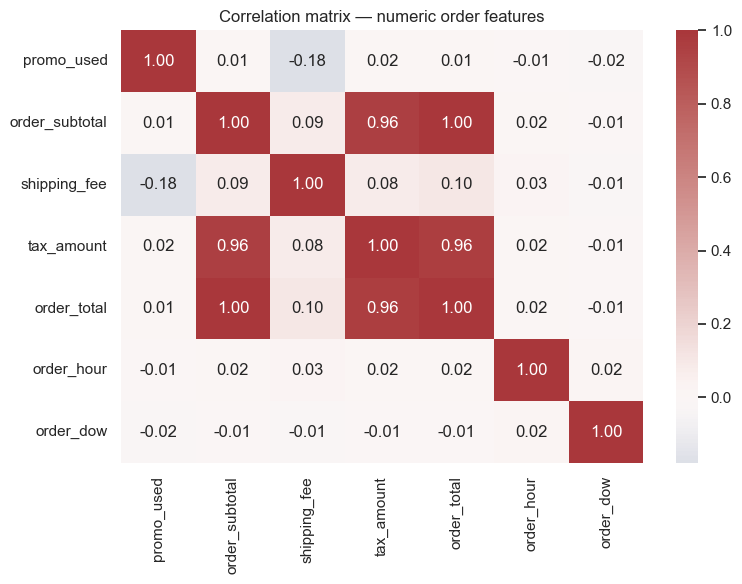

In [7]:
# Ch. 8 — correlation among numeric features (excluding target)
cm = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix — numeric order features")
plt.tight_layout()
plt.show()


In [8]:
# Categorical frequencies vs fraud rate (exploratory)
for col in ["payment_method", "device_type", "ip_country"]:
    ct = pd.crosstab(df[col], df["is_fraud"], normalize="index")
    ct.columns = ["legit_share", "fraud_share"]
    print(col)
    print(ct.sort_values("fraud_share", ascending=False).head(10))


payment_method
                legit_share  fraud_share
payment_method                          
crypto             0.896907     0.103093
card               0.932566     0.067434
bank               0.940690     0.059310
paypal             0.948571     0.051429
device_type
             legit_share  fraud_share
device_type                          
mobile          0.931968     0.068032
tablet          0.934066     0.065934
desktop         0.943248     0.056752
ip_country
            legit_share  fraud_share
ip_country                          
IN             0.905263     0.094737
GB             0.913462     0.086538
BR             0.926829     0.073171
CA             0.931193     0.068807
NG             0.934783     0.065217
US             0.937959     0.062041


## 3) Data preparation & wrangling (Ch. 2–4, 7)

**Ch. 2–4:** Clean types, handle missing categoricals, avoid leakage.

**Ch. 7 — Automated preparation:** sklearn `Pipeline` + `ColumnTransformer` so training and deployment share **one** reproducible workflow.

**Feature engineering (this notebook):** `order_hour` and `order_dow` derived from `order_datetime` (timing patterns often matter for fraud).

**Feature set:** categoricals (one-hot) + numeric (scaled). **`risk_score`** excluded (leakage). **`promo_code`** omitted (high cardinality); extend as needed.


In [9]:
TARGET = "is_fraud"
DROP = {"order_id", "customer_id", "order_datetime", "is_fraud"}
# Note: risk_score is NOT loaded from SQL (avoid label leakage).

feature_cols = [c for c in df.columns if c not in DROP and c != TARGET]

# Treat non-numeric dtypes (object, string, category, boolean) as categorical for OHE;
# pandas StringDtype is not `== object`, so use is_numeric_dtype.
cat_cols = [c for c in feature_cols if not is_numeric_dtype(df[c])]
num_cols = [c for c in feature_cols if is_numeric_dtype(df[c])]

# Fill missing strings for OHE
for c in cat_cols:
    df[c] = df[c].fillna("missing").astype(str)

X = df[feature_cols]
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4000, 16) Test: (1001, 16)


In [10]:
def make_preprocess():
    return ColumnTransformer(
        [
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                cat_cols,
            ),
            ("num", StandardScaler(), num_cols),
        ]
    )

preprocess = make_preprocess()


## 4) Classification modeling (Ch. 13) & ensembles (Ch. 14)

**Ch. 13 — Classification:** logistic regression **baseline**; **nonlinear** decision boundaries via tree ensembles.

**Ch. 14 — Ensembles:** **Random Forest** (bagging + randomized trees) and **Gradient Boosting** (sequential error correction).

All models share the **same preprocessing** pipeline for fair comparison.


In [11]:
def eval_model(name, pipe):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, proba))
    print("F1:", f1_score(y_test, pred))
    print(classification_report(y_test, pred, digits=3))
    return pipe

baseline = Pipeline(
    [("prep", make_preprocess()), ("clf", LogisticRegression(max_iter=2000, random_state=RNG))]
)
eval_model("LogisticRegression (baseline)", baseline)

rf_pipe = Pipeline(
    [
        ("prep", make_preprocess()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=None,
                min_samples_leaf=5,
                random_state=RNG,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)
rf_model = eval_model("RandomForest (ensemble)", rf_pipe)

gb_pipe = Pipeline(
    [
        ("prep", make_preprocess()),
        (
            "clf",
            GradientBoostingClassifier(
                random_state=RNG,
                n_estimators=150,
                learning_rate=0.08,
                max_depth=3,
            ),
        ),
    ]
)
gb_model = eval_model("GradientBoosting (ensemble)", gb_pipe)


=== LogisticRegression (baseline) ===
Accuracy: 0.9340659340659341
ROC-AUC: 0.7435465581643543
F1: 0.029411764705882353
              precision    recall  f1-score   support

           0      0.937     0.997     0.966       937
           1      0.250     0.016     0.029        64

    accuracy                          0.934      1001
   macro avg      0.593     0.506     0.498      1001
weighted avg      0.893     0.934     0.906      1001



=== RandomForest (ensemble) ===
Accuracy: 0.7842157842157842
ROC-AUC: 0.7235692369263607
F1: 0.22302158273381295
              precision    recall  f1-score   support

           0      0.958     0.805     0.875       937
           1      0.145     0.484     0.223        64

    accuracy                          0.784      1001
   macro avg      0.551     0.645     0.549      1001
weighted avg      0.906     0.784     0.833      1001



=== GradientBoosting (ensemble) ===
Accuracy: 0.9330669330669331
ROC-AUC: 0.7342666088580576
F1: 0.028985507246376812
              precision    recall  f1-score   support

           0      0.937     0.996     0.965       937
           1      0.200     0.016     0.029        64

    accuracy                          0.933      1001
   macro avg      0.568     0.506     0.497      1001
weighted avg      0.890     0.933     0.905      1001



## 5) Evaluation, model selection & tuning (Ch. 15)

Compare models on **held-out** data; address **class imbalance** via `class_weight` / ROC-AUC / F1.

**Hyperparameter tuning:** `GridSearchCV` with **stratified k-fold** on **Random Forest** (strong baseline, tunable).


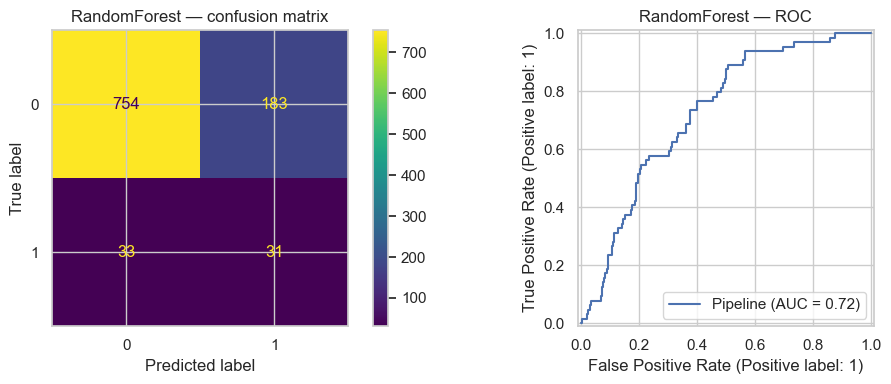

In [12]:
# Confusion matrix + ROC for best hand-picked ensemble (RF)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax[0])
ax[0].set_title("RandomForest — confusion matrix")
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax[1])
ax[1].set_title("RandomForest — ROC")
plt.tight_layout()
plt.show()


In [13]:
param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 12, 20],
    "clf__min_samples_leaf": [1, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)
grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_rf = grid.best_estimator_
proba = best_rf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print("Test ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, digits=3))


Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Best CV ROC-AUC: 0.7298630324930776
Test ROC-AUC: 0.7265875133404482
              precision    recall  f1-score   support

           0      0.960     0.798     0.872       937
           1      0.149     0.516     0.231        64

    accuracy                          0.780      1001
   macro avg      0.554     0.657     0.551      1001
weighted avg      0.908     0.780     0.831      1001



## 6) Feature selection (Ch. 16)

**Goal:** reduce variance / complexity by keeping inputs with strong signal.

Approach: **`SelectFromModel`** using **RandomForest** `feature_importances_` fitted on **preprocessed** data. We embed selection **after** preprocessing inside a single `Pipeline` for deployment consistency.

*Alternative (also valid):* mutual information on numeric columns only, or L1 logistic regression for sparse linear selection.


In [14]:
# Pipeline: preprocess -> RF (for importance) -> select threshold -> final RF
prep = make_preprocess()
Xtr = prep.fit_transform(X_train, y_train)
Xte = prep.transform(X_test)

rf_sel = RandomForestClassifier(
    n_estimators=200,
    random_state=RNG,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_sel.fit(Xtr, y_train)

selector = SelectFromModel(rf_sel, prefit=True, threshold="median")
Xtr_s = selector.transform(Xtr)
Xte_s = selector.transform(Xte)

final_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RNG,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
final_rf.fit(Xtr_s, y_train)
proba_s = final_rf.predict_proba(Xte_s)[:, 1]
print("After feature selection — Test ROC-AUC:", roc_auc_score(y_test, proba_s))

# For deployment, a single sklearn Pipeline is cleaner; we refit the winning GridSearch model
# and document feature selection as an analysis step above.
selected_support = selector.get_support()
print("Features kept after selection:", int(selected_support.sum()), "/", len(selected_support))


After feature selection — Test ROC-AUC: 0.7138390474919957
Features kept after selection: 427 / 854


## 7) Deployment — serialization & connection to Vercel + Turso (Ch. 17)

### Serialized artifact (this notebook)

We save **one sklearn `Pipeline`** (preprocessing + tuned estimator) with **`joblib`** as:

`ShopWeb/MLModels/fraud_sklearn_pipeline.joblib`

Load in Python with `joblib.load`, then call **`predict_proba`** on a DataFrame with the **same feature columns** as training (after any offline feature engineering you add).

### How this ties to your deployed site (`web/` on Vercel)

| Piece | Role |
|-------|------|
| **Turso (libSQL)** | Production DB: set **`TURSO_DATABASE_URL`** and **`TURSO_AUTH_TOKEN`** in Vercel → Settings → Environment Variables. Tables **`orders`** / **`customers`** match the SQLite file used here, so training features align with live rows. |
| **Next.js app** | Serves the shop UI, admin history, and **Verification queue** (orders sorted by **`risk_score`**). |
| **Run scoring** | Server action updates **`orders.risk_score`** in the database so the queue reflects current risk. On Vercel, scoring uses the **TypeScript heuristic** in `web/src/lib/scoring.ts` (Node cannot load Python `joblib` on the edge). |
| **This trained model** | **Chapter 17 ML artifact:** batch/offline scoring, periodic retraining on refreshed exports, or future **ONNX** / Python API — same fraud problem the site operationalizes via **`risk_score`** and priority ordering. |

**Submit for the assignment:** upload this **one** `.ipynb` file with all cells run (outputs visible).


In [15]:
DEPLOY_DIR = Path("../ShopWeb/MLModels")
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)
artifact = DEPLOY_DIR / "fraud_sklearn_pipeline.joblib"

# Ship the tuned Random Forest pipeline (best from GridSearchCV)
joblib.dump(grid.best_estimator_, artifact)
print("Saved:", artifact.resolve())

# Smoke test load
proba_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
loaded = joblib.load(artifact)
assert np.allclose(loaded.predict_proba(X_test)[:, 1], proba_test, atol=1e-6)
print("Load/predict smoke test OK.")


Saved: /Users/isaacfox/FoxIS455DeploymentAssignment-1/ShopWeb/MLModels/fraud_sklearn_pipeline.joblib
Load/predict smoke test OK.


## Summary

| Phase | What we did |
|-------|-------------|
| Business | Defined fraud detection objective & success metrics |
| Data understanding | SQLite load, summaries, correlations, fraud rates by category |
| Preparation | `ColumnTransformer` + OHE + scaling; stratified split |
| Modeling | Logistic regression, Random Forest, Gradient Boosting |
| Evaluation / tuning | Metrics, ROC, confusion matrix, `GridSearchCV` |
| Feature selection | `SelectFromModel` (median threshold) |
| Deployment | `joblib` → `ShopWeb/MLModels/fraud_sklearn_pipeline.joblib`; live site uses Turso + heuristic scoring on Vercel; schema matches training DB |

**Next steps:** drift monitoring, threshold tuning for queue capacity, optional ONNX for cross-runtime inference.
